# Customer Intelligence / Country Segmentation Notebook

## Unsupervised Learning on Country Data

This notebook helps interns learn a full clustering workflow using the Kaggle dataset **Unsupervised Learning on Country Data**.

### Goals
- Load and inspect the data
- Clean and preprocess features
- Apply scaling
- Find the best number of clusters with K-Means
- Try DBSCAN as a second clustering method
- Visualize clusters with PCA
- Create simple country-level insights


## 1) Install required libraries

In [2]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn

## 2) Import libraries

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## 3) Load the dataset

Upload the CSV file from Kaggle when prompted.


In [4]:
import pandas as pd

df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 4) Quick inspection

In [5]:
print('Shape:', df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## 5) Expected columns

This dataset is commonly used for country clustering and usually contains:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp


In [6]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [7]:

df.columns = df.columns.str.strip()

df = df.drop_duplicates()

for col in df.columns:
    if col.lower() != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
df.head()

Dataset Shape: (167, 10)

Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## 7) Exploratory Data Analysis

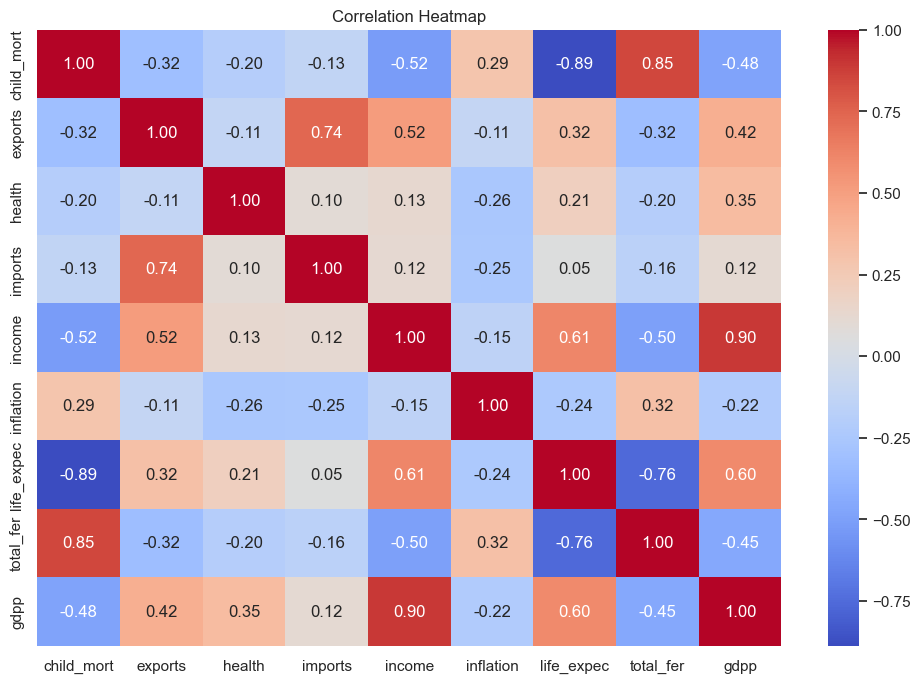

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

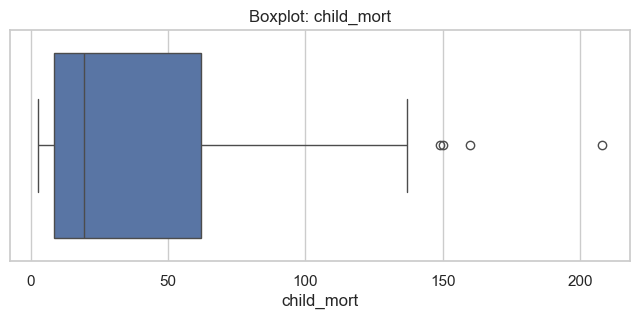

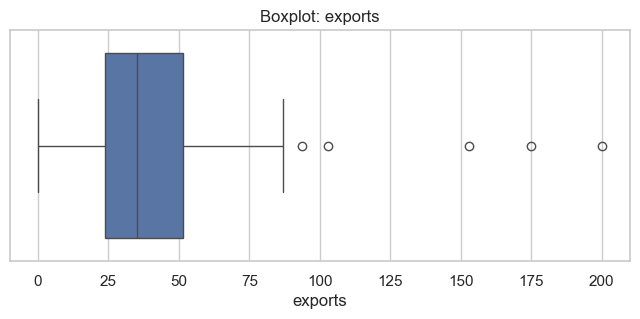

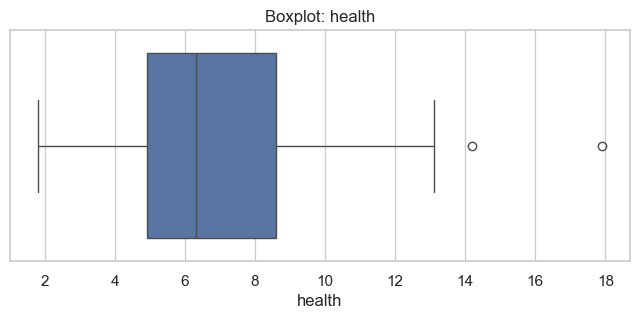

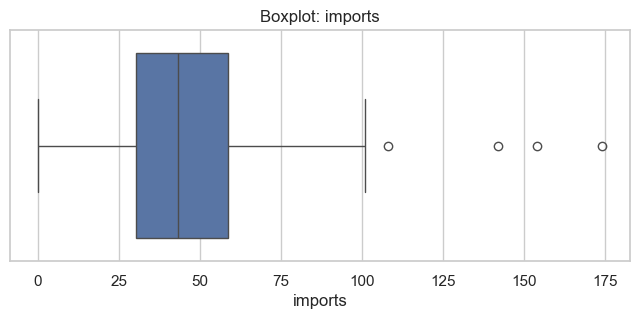

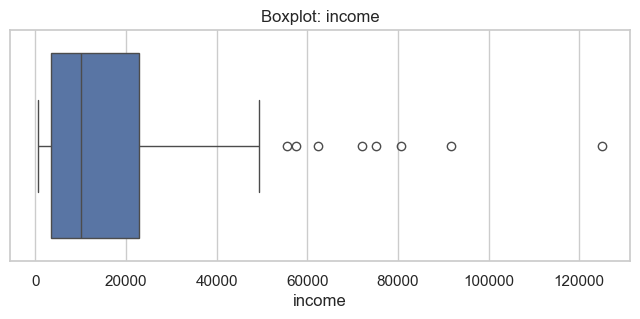

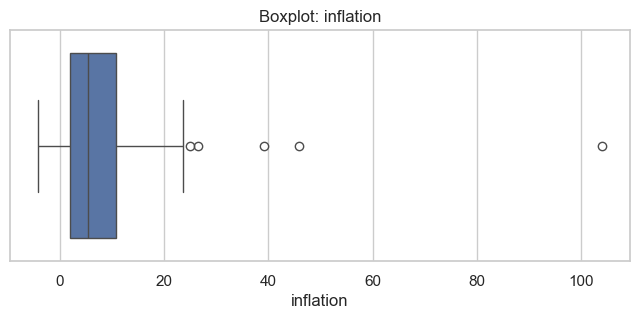

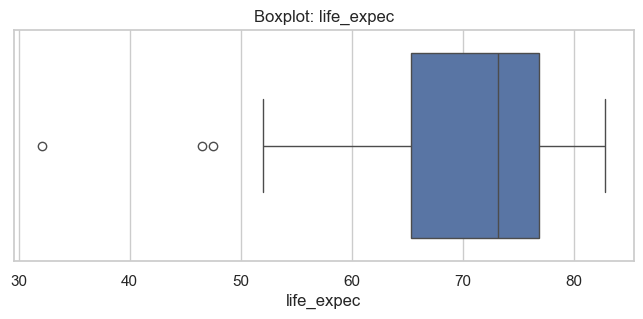

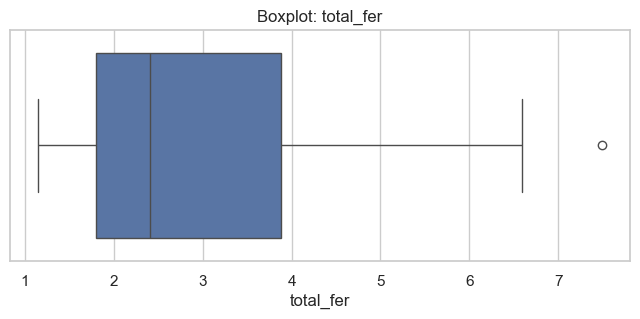

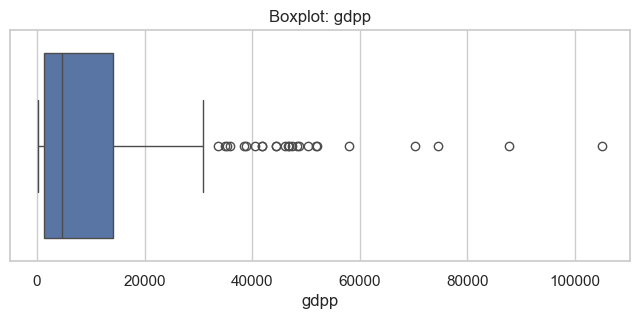

In [9]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

## 8) Feature scaling

Clustering works better when features are on the same scale.

In [10]:
features = df.drop(columns=['country'], errors='ignore')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.shape

(167, 9)

## 9) K-Means: Clustering


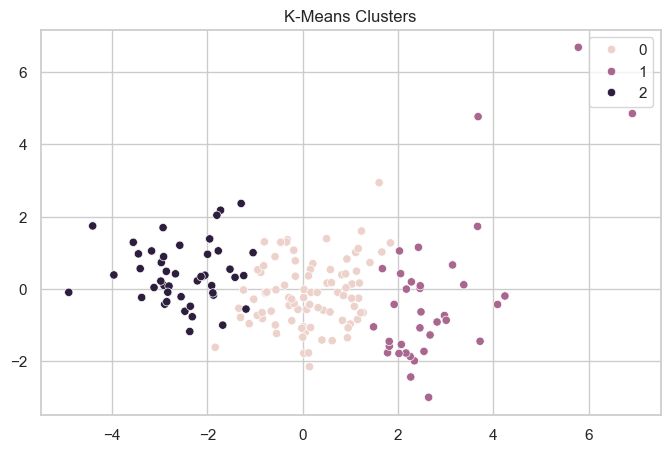

In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters
)

plt.title("K-Means Clusters")

plt.show()

## 10) Train K-Means

In [12]:
best_k = 3  
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Silhouette Score:', silhouette_score(X_scaled, df['kmeans_cluster']))
df[['country', 'kmeans_cluster']].head() if 'country' in df.columns else df[['kmeans_cluster']].head()

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['kmeans_cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.28329575683463126
Silhouette Score: 0.28329575683463126


## 11) Try DBSCAN

In [13]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64


## 12) PCA visualization

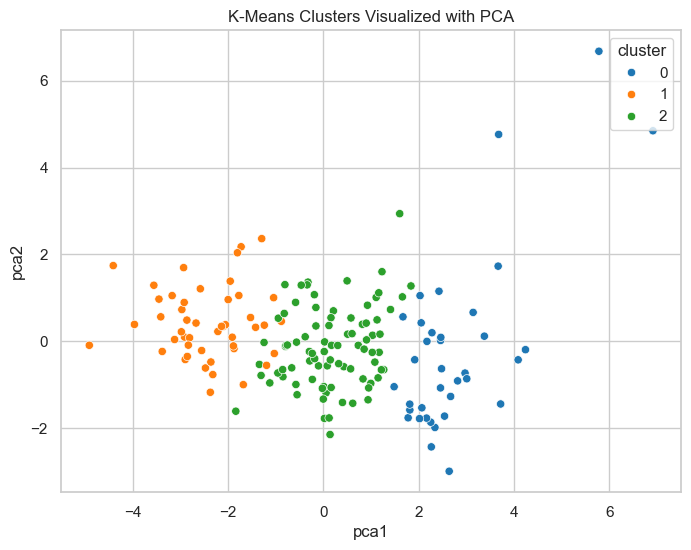

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz = pd.DataFrame({
    'pca1': X_pca[:, 0],
    'pca2': X_pca[:, 1],
    'cluster': df['kmeans_cluster']
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=viz, x='pca1', y='pca2', hue='cluster', palette='tab10')
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

## 13) Cluster profiling

In [15]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


## 14) Final insights

Write 3 to 5 observations about the clusters:
- Which cluster has high child mortality?
- Which cluster has high income and gdpp?
- Which cluster looks underdeveloped?
- Which countries should be prioritized for aid?


## 14) Final Insights

1. **Cluster 1 has the highest child mortality** (92.96), the lowest average income (3942.40), and the lowest GDP per capita (1923.38). This cluster represents the most underdeveloped countries.

2. **Cluster 0 has the highest average income** (45672.22), the highest GDP per capita (42494.44), and the highest life expectancy (80.13). This cluster represents the most economically developed countries.

3. **Cluster 2 represents developing countries**, with moderate child mortality (21.93), income (12305.60), GDP per capita (6486.45), and life expectancy (72.81). It lies between the developed and underdeveloped groups.

4. **Countries in Cluster 1 should be prioritized for aid** because they have poor economic conditions, high child mortality, and lower life expectancy, indicating a greater need for healthcare and economic support.

5. The K-Means model successfully divided countries into three meaningful socio-economic groups, while the silhouette score of approximately **0.28** indicates moderate clustering quality.



In [17]:
cluster_summary = df.groupby('kmeans_cluster').mean(numeric_only=True)

cluster_summary[['child_mort', 'income', 'gdpp', 'life_expec']]

,child_mort,income,gdpp,life_expec
kmeans_cluster,,,,
0,5.000000,45672.222222,42494.444444,80.127778
1,92.961702,3942.404255,1922.382979,59.187234
2,21.927381,12305.595238,6486.452381,72.814286


In [18]:
# Features and Target

X = X_scaled
y = df['kmeans_cluster']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (133, 9)
Test Shape : (34, 9)


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_acc)

print(classification_report(y_test, rf_pred))

Random Forest Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy :", xgb_acc)

print(classification_report(y_test, xgb_pred))

XGBoost Accuracy : 0.9411764705882353
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.90      0.95        10
           2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



In [21]:
comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        rf_acc,
        xgb_acc
    ]

})

comparison

,Model,Accuracy
0,Random Forest,1.000000
1,XGBoost,0.941176


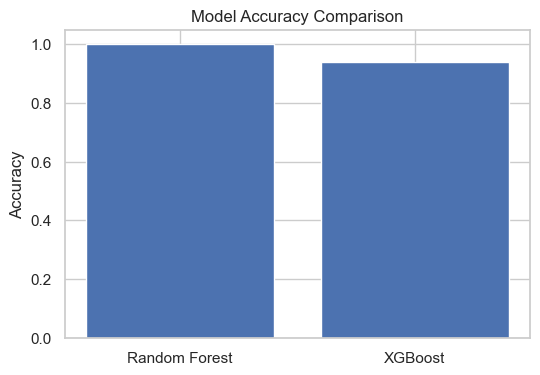

In [22]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

In [23]:
importance = pd.DataFrame({

    "Feature":features.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,child_mort,0.258356
8,gdpp,0.197672
7,total_fer,0.174131
6,life_expec,0.166180
4,income,0.144466
2,health,0.025791
5,inflation,0.016371
3,imports,0.009472
1,exports,0.007561


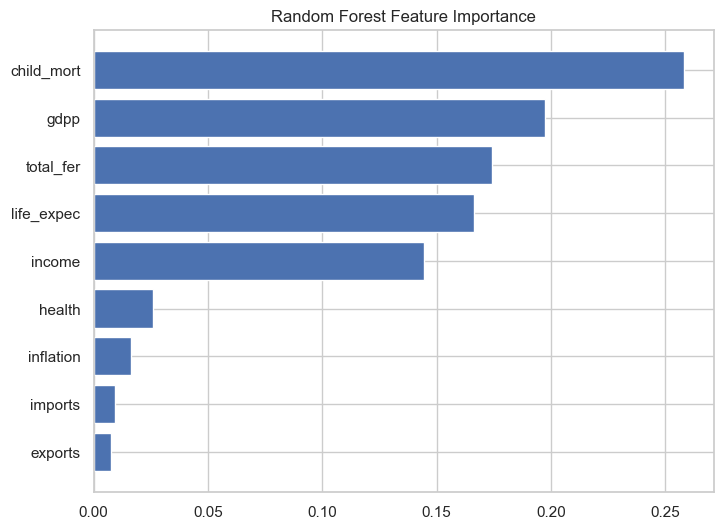

In [24]:
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [25]:
print("Customer Intelligence Insights")

print("-"*40)

print("1. Cluster 0 represents developing countries with moderate socio-economic indicators.")

print("2. Cluster 1 consists of underdeveloped countries with high child mortality and low income.")

print("3. Cluster 2 contains developed countries with high income, high GDP per capita and better health.")

print("4. Countries in Cluster 1 should be prioritized for financial aid and healthcare support.")

print("5. Income and GDP are among the strongest factors influencing segmentation.")

Customer Intelligence Insights
----------------------------------------
1. Cluster 0 represents developing countries with moderate socio-economic indicators.
2. Cluster 1 consists of underdeveloped countries with high child mortality and low income.
3. Cluster 2 contains developed countries with high income, high GDP per capita and better health.
4. Countries in Cluster 1 should be prioritized for financial aid and healthcare support.
5. Income and GDP are among the strongest factors influencing segmentation.
